In [2]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [3]:
df = pd.read_csv("C:\\Users\\User\\Documents\\ДЗ\\birulevo sentiment coded.csv")
df

,user,tweet,SENTIMENT,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,NaN,1.0,POSITIVE
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1,NaN,2.0,NEUTRAL
2,White_technolog,у районной управы собираются местные жители #б...,2,NaN,3.0,NEGATIVE
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2,NaN,NaN,NaN
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3,NaN,NaN,NaN
...,...,...,...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2,NaN,NaN,NaN
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2,NaN,NaN,NaN
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3,NaN,NaN,NaN
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2,NaN,NaN,NaN


In [4]:
df.isna().sum()

user             1
tweet            1
SENTIMENT        1
Unnamed: 3    1891
Unnamed: 4    1888
Unnamed: 5    1888
dtype: int64

In [5]:
df=df[['user','tweet','SENTIMENT']]
df = df.dropna()
df

,user,tweet,SENTIMENT
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1
2,White_technolog,у районной управы собираются местные жители #б...,2
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,"как пишет товарищ в смс, на площади революции ...",3
...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2


In [6]:
tmp_df=df.groupby('user').agg('count')
tmp_df

,tweet,SENTIMENT
user,,
BorisALV,100,100
CallmJoker,28,28
EP_IKS,1,1
Estraniero,45,45
FederalPress,32,32
Fkontakte,4,4
GraniTweet,27,27
I_M_HO,1,1
MedvedRu,51,51


<Axes: xlabel='user', ylabel='tweet'>

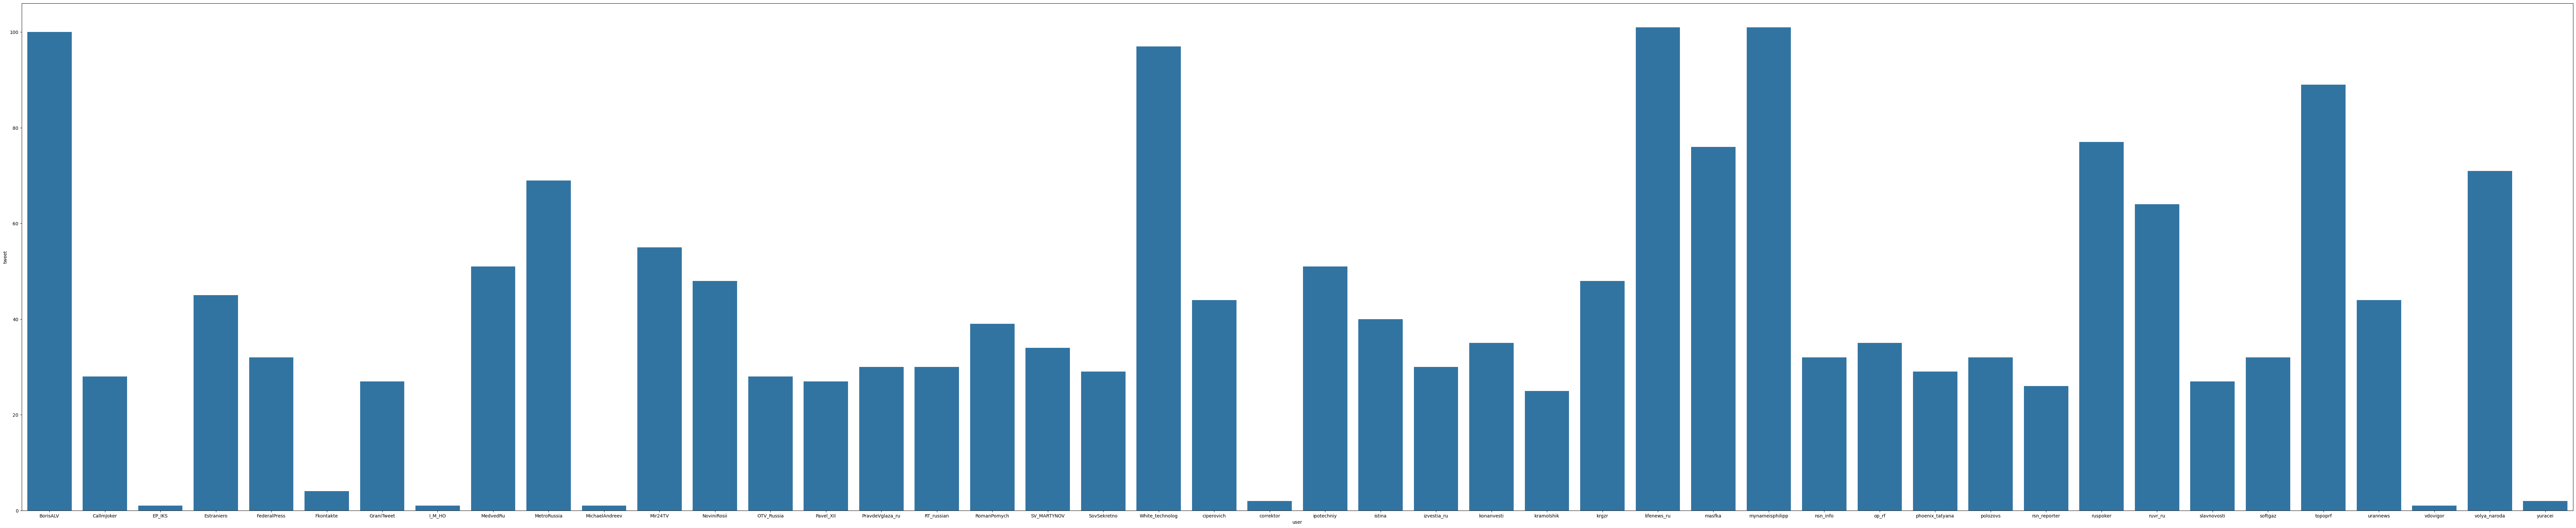

In [41]:
fig, ax = plt.subplots(figsize=(100, 20))
sns.barplot(x=tmp_df.index,y=tmp_df['tweet'],ax=ax)

In [8]:
##классы не сбалансированы

In [9]:
import re

In [10]:
## Приводим текст к нижнему регистру
df['tweet'] = df['tweet'].str.lower()
df

,user,tweet,SENTIMENT
1,BorisALV,в вост. #бирюлево на одну палатку с кошатиной ...,1
2,White_technolog,у районной управы собираются местные жители #б...,2
3,White_technolog,“@tvrain: тем временем конная полиция добралас...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,"как пишет товарищ в смс, на площади революции ...",3
...,...,...,...
1886,GraniTweet,наш корр @dmitryhorse ведет трансляцию из #бир...,2
1887,Fkontakte,“@gazetaru: #мид ответил на заявление германии...,2
1888,Fkontakte,“@rt_russian: #азербайджан'ские радикалы пригр...,3
1889,Fkontakte,“@rt_russian: эксклюзив: новые кадры задержани...,2


In [11]:
## Убираем все знаки препинания
df['tweet'] = df['tweet'].str.replace(r'[^\w\s]', '', regex=True)
df

,user,tweet,SENTIMENT
1,BorisALV,в вост бирюлево на одну палатку с кошатиной ст...,1
2,White_technolog,у районной управы собираются местные жители би...,2
3,White_technolog,tvrain тем временем конная полиция добралась д...,2
4,White_technolog,в центре появились тощие прыщавые мужичонки с ...,3
5,White_technolog,как пишет товарищ в смс на площади революции ч...,3
...,...,...,...
1886,GraniTweet,наш корр dmitryhorse ведет трансляцию из бирюлево,2
1887,Fkontakte,gazetaru мид ответил на заявление германии о б...,2
1888,Fkontakte,rt_russian азербайджанские радикалы пригрозили...,3
1889,Fkontakte,rt_russian эксклюзив новые кадры задержания по...,2


In [12]:
##Преобразовать датасет в TF-IDF, поделить на треин-тест и спрогнозировать моделью SVM
X = df['tweet']
y = df['user']

In [13]:
X

1       в вост бирюлево на одну палатку с кошатиной ст...
2       у районной управы собираются местные жители би...
3       tvrain тем временем конная полиция добралась д...
4       в центре появились тощие прыщавые мужичонки с ...
5       как пишет товарищ в смс на площади революции ч...
                              ...                        
1886    наш корр dmitryhorse ведет трансляцию из бирюлево
1887    gazetaru мид ответил на заявление германии о б...
1888    rt_russian азербайджанские радикалы пригрозили...
1889    rt_russian эксклюзив новые кадры задержания по...
1890    предполагаемый убийца егора щербакова в бирюле...
Name: tweet, Length: 1890, dtype: object

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    ##stratify=y  #т.к классы несбалансированны - не работал код поэтому пока закомментил
)

In [15]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words_ru = list(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,         
        stop_words=stop_words_ru,    
        ngram_range=(1, 2),      # униграммы + биграммы  (пары соседних слов)
        max_df=0.95,             # игнорировать слишком частые слова
        min_df=2                 # игнорировать слишком редкие слова
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced', # классы несбалансированы
        max_iter=10000
    ))
])

In [17]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5026455026455027

Classification report:
                  precision    recall  f1-score   support

       BorisALV       0.44      0.17      0.24        24
     CallmJoker       0.00      0.00      0.00         4
         EP_IKS       0.00      0.00      0.00         1
     Estraniero       0.27      0.75      0.40         4
   FederalPress       0.25      0.67      0.36         3
     GraniTweet       0.25      0.11      0.15         9
       MedvedRu       0.50      0.27      0.35        11
    MetroRussia       0.10      0.17      0.12         6
 MichaelAndreev       0.00      0.00      0.00         1
        Mir24TV       0.92      1.00      0.96        12
    NoviniRosii       0.56      0.62      0.59         8
     OTV_Russia       0.50      0.75      0.60         4
      Pavel_XII       0.00      0.00      0.00         6
PravdeVglaza_ru       0.89      1.00      0.94         8
     RT_russian       0.50      0.43      0.46         7
    RomanPomych       0.19      0

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packag

In [18]:
##Уровень 2 удалить слова используя стеммер Портера

In [19]:
from nltk.stem import PorterStemmer
Porter=PorterStemmer()
def stem_sentence(sentence):
    stemmed_words = []
    for word in sentence.split():
        stemmed_words.append(Porter.stem(word))
    return ' '.join(stemmed_words)

In [20]:
(Porter.stem('первый'))

'первый'

In [21]:
for text in X:
    print(stem_sentence(text))

в вост бирюлево на одну палатку с кошатиной стало меньше live
у районной управы собираются местные жители бирюлево live whitepow
tvrain тем временем конная полиция добралась до бирюлева pictwittercomblrf074rmj бирюлево live бунт
в центре появились тощие прыщавые мужичонки с красными повязками дружинник live бунт москва бирюлево
как пишет товарищ в смс на площади революции черным черно в смысле орды черножопых live бирюлево москва
на стм пушкинская 6 полицейских с дубинками и касками один черножопый москва live бирюлево
в вост бирюлево на одну палатку с кошатиной стало меньше live
amnesti intern массовые задержания мигрантов в москве это нарушение прав httpamnestyorgrunode2628 новости сми бирюлево навальный
рт молния зомби в бирюлево нападают на всех они повсюду спорт россии гринпис novosti russia news путин pictwittercomeiojqusphz
бирюлевский убийца зейналов рвется на свободу httpbitly16jkdua бирюлево москва moscow russia news
в бирюлево найден убитым гражданин узбекистана httpbitly17s

In [22]:
# Сетка параметров
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],          # униграммы vs униграммы+биграммы
    'tfidf__max_df': [0.9, 0.95],                    # доля документов, выше которой слово игнорируется
    'tfidf__min_df': [1, 2, 5],                     # минимальная частота документа
    'svm__C': [0.1, 1.0, 10.0]                      # сила регуляризации SVM
}

# GridSearch
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,                                           # 5 фолдов кросс‑валидации
    scoring='f1_macro',                             # хорошо для несбалансированных классов (как в sentiment)
    n_jobs=-1,                                      # использовать все ядра
    verbose=1                                       # показывать прогресс
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший CV score (F1 macro):", grid_search.best_score_)

# Оценка на тесте
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nTest F1 macro:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Лучшие параметры: {'svm__C': 10.0, 'tfidf__max_df': 0.95, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Лучший CV score (F1 macro): 0.3736327369533893

Test F1 macro: 0.4486473436410732
                 precision    recall  f1-score   support

       BorisALV       0.38      0.21      0.27        24
     CallmJoker       0.25      0.25      0.25         4
         EP_IKS       0.00      0.00      0.00         1
     Estraniero       0.17      0.50      0.25         4
   FederalPress       0.17      0.33      0.22         3
     GraniTweet       0.25      0.11      0.15         9
       MedvedRu       0.43      0.27      0.33        11
    MetroRussia       0.12      0.50      0.19         6
 MichaelAndreev       0.00      0.00      0.00         1
        Mir24TV       0.86      1.00      0.92        12
    NoviniRosii       0.89      1.00      0.94         8
     OTV_Russia       0.60      0.75      0.67         4
      Pavel_XII       0.33      0.17      0.22         6
PravdeVglaz

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
##Уровень 3

In [24]:
##Использовать лемматизатор pymorphy вместо стемминга

In [25]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

def stem_morph_sentence(sentence):
    stemmed_morph_words = []
    for word in sentence.split():
        stemmed_morph_words.append((morph.parse(word)[0]).normal_form)
    return ' '.join(stemmed_morph_words)

In [26]:
for text in X:
    print(stem_morph_sentence(text))

в вост бирюлёво на один палатка с кошатина стать маленький live
у районный управа собираться местный житель бирюлёво live whitepower
tvrain тем время конный полиция добраться до бирюлев pictwittercomblrf074rmj бирюлёво live бунт
в центр появиться тощий прыщавый мужичонка с красный повязка дружинник live бунт москва бирюлёво
как писать товарищ в смс на площадь революция чёрный черно в смысл орда черножопый live бирюлёво москва
на стм пушкинский 6 полицейский с дубинка и каска один черножопый москва live бирюлёво
в вост бирюлёво на один палатка с кошатина стать маленький live
amnesty international массовый задержание мигрант в москва это нарушение право httpamnestyorgrunode2628 новость сми бирюлёво навальный
рт молния зомби в бирюлёво нападать на весь они повсюду спорт россия гринпис novosti russia news путин pictwittercomeiojqusphz
бирюлёвский убийца зейнал рваться на свобода httpbitly16jkdua бирюлёво москва moscow russia news
в бирюлёво найти убитый гражданин узбекистан httpbitly17syck

In [27]:
##Использовать word2vec вместо tf-idf.

In [28]:
from gensim.models import Word2Vec

In [29]:
model_w2v = Word2Vec(sentences=X, vector_size=100, window=5, min_count=1,)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [30]:
def doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        # если ни одно слово не попало в словарь — нулевой вектор
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack(X.apply(lambda t: doc_vector(t, model_w2v)))

In [31]:
X_w2v ## матрица (n_samples, vector_size)

array([[-0.34112924,  0.45601133,  0.05126883, ..., -0.2236745 ,
         0.27718395,  0.08478359],
       [-0.27734932,  0.2412989 ,  0.18299025, ..., -0.12311233,
         0.23659217,  0.15152279],
       [-0.17757598,  0.0974231 ,  0.23548822, ..., -0.02978347,
         0.16857995,  0.14159644],
       ...,
       [-0.2148942 ,  0.13341098,  0.19559793, ..., -0.05266072,
         0.17653093,  0.12504876],
       [-0.185659  ,  0.03445214,  0.2496425 , ..., -0.04377035,
         0.15489253,  0.17267698],
       [-0.3255182 ,  0.56177896,  0.01386492, ..., -0.31248677,
         0.2850189 ,  0.07010209]], shape=(1890, 100), dtype=float32)

In [32]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_w2v, y,
    test_size=0.2,
    random_state=42
)

In [33]:
pipe = LinearSVC(class_weight='balanced', max_iter=10000)

param_grid = {
    'C': [0.1, 1.0, 10.0]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train2, y_train2)

print("Лучший C:", grid.best_params_)
print("Лучший CV F1 macro:", grid.best_score_)

y_pred2 = grid.predict(X_test2)
print("\nTest F1 macro:", f1_score(y_test2, y_pred2, average='macro'))
print(classification_report(y_test2, y_pred2))

Fitting 5 folds for each of 3 candidates, totalling 15 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Лучший C: {'C': 10.0}
Лучший CV F1 macro: 0.23978787720060693

Test F1 macro: 0.25356232120051114
                 precision    recall  f1-score   support

       BorisALV       0.29      0.08      0.13        24
     CallmJoker       0.00      0.00      0.00         4
         EP_IKS       0.00      0.00      0.00         1
     Estraniero       0.00      0.00      0.00         4
   FederalPress       0.17      0.67      0.27         3
      Fkontakte       0.00      0.00      0.00         0
     GraniTweet       0.60      0.33      0.43         9
         I_M_HO       0.00      0.00      0.00         0
       MedvedRu       0.14      0.09      0.11        11
    MetroRussia       0.25      0.17      0.20         6
 MichaelAndreev       0.00      0.00      0.00         1
        Mir24TV       0.58      0.92      0.71        12
    NoviniRosii       0.25      0.50      0.33         8
     OTV_Russia       0.25      0.75      0.38         4
      Pavel_XII       0.00      0.00      0.00

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packag

In [34]:
##

In [35]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [36]:
from catboost import CatBoostClassifier

In [37]:
model_cat = CatBoostClassifier(
    iterations=500,
    depth=4,
    learning_rate=0.1,
    loss_function='MultiClass',          
    verbose=0,                           
    random_seed=42,
    auto_class_weights='Balanced'              
)

In [42]:
param_grid2 = {
    'depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1],
    'iterations': [200, 300]
}
grid = GridSearchCV(
    model_cat,
    param_grid2,
    cv=5,
    scoring='f1_macro',
    n_jobs=2,
    verbose=1, 
)

grid.fit(X_train2, y_train2)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV F1 macro:", grid.best_score_)

best_model = grid.best_estimator_
y_pred3 = best_model.predict(X_test2)

print("\nTest F1 macro:", f1_score(y_test2, y_pred3, average='macro'))
print(classification_report(y_test2, y_pred3))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Лучшие параметры: {'depth': 5, 'iterations': 300, 'learning_rate': 0.1}
Лучший CV F1 macro: 0.3011053475808342

Test F1 macro: 0.333341460480608
                 precision    recall  f1-score   support

       BorisALV       0.60      0.25      0.35        24
     CallmJoker       0.00      0.00      0.00         4
         EP_IKS       0.00      0.00      0.00         1
     Estraniero       0.25      0.25      0.25         4
   FederalPress       0.20      0.33      0.25         3
      Fkontakte       0.00      0.00      0.00         0
     GraniTweet       0.29      0.22      0.25         9
         I_M_HO       0.00      0.00      0.00         0
       MedvedRu       0.40      0.36      0.38        11
    MetroRussia       0.14      0.17      0.15         6
 MichaelAndreev       0.00      0.00      0.00         1
        Mir24TV       0.65      0.92      0.76        12
    NoviniRosii       0.29      0.50      0.36         8
     OTV_Russia       0.30      0.75      0.43         4

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packag